# 1. Introduction

In this notebook, we simulate two artificial worlds for diabetes prediction:

Fair world:
Gender does NOT influence the glucose measurement.

Biased world:
Gender DOES influence glucose measurement (women get inflated glucose levels).

We train the same machine learning model on both datasets and compute:

TPR (True Positive Rate)

FPR (False Positive Rate)

Equalized Odds difference

Visual barplots of fairness metrics

This allows us to test whether fairness metrics can detect bias when it is introduced on purpose.

In [290]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


 # 2. Graphical Model

 # 3. Simulator

In [291]:
import numpy as np
import pandas as pd

# Common parameters for both worlds
HBA1C_MEAN = 5.7
HBA1C_SD   = 0.8        # moderate spread
PROCESS_SD = 10         # noise in physiology (glucose_true)
MEAS_SD    = 3          # realistic lab measurement noise
THRESHOLD  = 126        # diabetes threshold (mg/dL)

def simulate_fair_world(n=20000, random_state=0):
    rng = np.random.default_rng(random_state)

    # 0 = Male, 1 = Female
    gender = rng.binomial(1, 0.5, n)

    # HbA1c ~ normal
    HbA1c = rng.normal(HBA1C_MEAN, HBA1C_SD, n)

    # True physiology: glucose_true depends on HbA1c + physiological noise
    glucose_true = HbA1c * 20 + rng.normal(0, PROCESS_SD, n)

    # Measured glucose: same noise for both genders
    glucose_measured = glucose_true + rng.normal(0, MEAS_SD, n)

    # True diabetes label depends ONLY on true glucose
    diabetes_true = (glucose_true > THRESHOLD).astype(int)

    return pd.DataFrame({
        "gender": gender,
        "HbA1c": HbA1c,
        "glucose_true": glucose_true,
        "glucose_measured": glucose_measured,
        "diabetes": diabetes_true
    })


def simulate_biased_world(n=20000, bias_strength=5.0, random_state=1):
    """
    bias_strength = systematic overestimation of glucose for women (in mg/dL)
    Example: bias_strength = 5 → women are measured +5 mg/dL higher than men
    """
    rng = np.random.default_rng(random_state)

    gender = rng.binomial(1, 0.5, n)
    HbA1c = rng.normal(HBA1C_MEAN, HBA1C_SD, n)

    glucose_true = HbA1c * 20 + rng.normal(0, PROCESS_SD, n)

    # Base measurement noise (same for all)
    base_meas = rng.normal(0, MEAS_SD, n)

    # Systematic bias: women (gender = 1) get + bias_strength mg/dL
    measurement_bias = bias_strength * (gender == 1)

    glucose_measured = glucose_true + base_meas + measurement_bias

    diabetes_true = (glucose_true > THRESHOLD).astype(int)

    return pd.DataFrame({
        "gender": gender,
        "HbA1c": HbA1c,
        "glucose_true": glucose_true,
        "glucose_measured": glucose_measured,
        "diabetes": diabetes_true
    })


In [292]:
df_fair = simulate_fair_world()
df_biased = simulate_biased_world()


# 4. Model & Prediction

In [293]:
def train_and_predict(df):
    X = df[["HbA1c", "glucose_measured"]]
    y = df["diabetes"]
    model = LogisticRegression()
    model.fit(X, y)
    return model.predict(X)


In [294]:
y_pred_fair = train_and_predict(df_fair)
y_pred_biased = train_and_predict(df_biased)

y_true_fair = df_fair["diabetes"].values
y_true_biased = df_biased["diabetes"].values


 # 5. Fairness Metrics

In [295]:
def compute_group_rates(df, y_true, y_pred):
    results = []
    for g in [0,1]:
        mask = df["gender"] == g
        tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask]).ravel()

        TPR = tp / (tp + fn)
        FPR = fp / (fp + tn)

        results.append({
            "Group": "Male" if g==0 else "Female",
            "TPR": TPR,
            "FPR": FPR
        })
    return pd.DataFrame(results)


In [296]:
def equalized_odds_diff(df_rates):
    TPR_diff = abs(df_rates.loc[0,"TPR"] - df_rates.loc[1,"TPR"])
    FPR_diff = abs(df_rates.loc[0,"FPR"] - df_rates.loc[1,"FPR"])
    return TPR_diff + FPR_diff


# 6. Simulations

In [297]:
# Simulate
df_fair   = simulate_fair_world(n=20000, random_state=0)
df_biased = simulate_biased_world(n=20000, bias_strength=5.0, random_state=1)

# Train & predict in both worlds
y_pred_fair   = train_and_predict(df_fair)
y_pred_biased = train_and_predict(df_biased)

# Ground truth labels
y_true_fair   = df_fair["diabetes"].values
y_true_biased = df_biased["diabetes"].values

# Compute fairness rates
df_rates_fair   = compute_group_rates(df_fair,   y_true_fair,   y_pred_fair)
df_rates_biased = compute_group_rates(df_biased, y_true_biased, y_pred_biased)

# Compute Equalized Odds
EO_fair   = equalized_odds_diff(df_rates_fair)
EO_biased = equalized_odds_diff(df_rates_biased)


# 7. Results

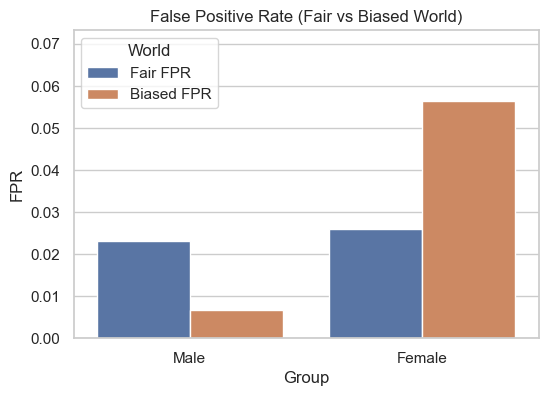

In [298]:
def plot_fpr_change(df_fair, df_biased):
    df = pd.DataFrame({
        "Group": ["Male","Female"],
        "Fair FPR": df_fair["FPR"],
        "Biased FPR": df_biased["FPR"]
    })

    df_melt = df.melt(id_vars="Group", value_vars=["Fair FPR","Biased FPR"],
                      var_name="World", value_name="FPR")

    plt.figure(figsize=(6,4))
    sns.barplot(data=df_melt, x="Group", y="FPR", hue="World")
    plt.title("False Positive Rate (Fair vs Biased World)")
    plt.ylim(0, max(df_melt["FPR"])*1.3)
    plt.show()

plot_fpr_change(df_rates_fair, df_rates_biased)


In [302]:
print("=== Fair World Rates ===")
print(df_rates_fair, "\n")

print("=== Biased World Rates ===")
print(df_rates_biased, "\n")

print("Equalized Odds:")
print("Fair world:", EO_fair)
print("Biased world:", EO_biased)


=== Fair World Rates ===
    Group       TPR       FPR
0    Male  0.924441  0.023164
1  Female  0.922583  0.025879 

=== Biased World Rates ===
    Group       TPR       FPR
0    Male  0.826908  0.006810
1  Female  0.969803  0.056323 

Equalized Odds:
Fair world: 0.004573515956922538
Biased world: 0.1924073935006457
